In [1]:
pip install -e ..

Obtaining file:///home/sagar/winogender_contextuality
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for winogender_contextuality (pyproject.toml) ... done
  Created wheel for winogender_contextuality: filename=winogender_contextuality-0.0.1-py3-none-any.whl size=3680 sha256=7eaeda3a55298dce1ac4d00ae011d0f0629bc206b66dd3eb3821d0ed21b9bdb9
  Stored in directory: /tmp/pip-ephem-wheel-cache-dq8fy3pu/wheels/f6/b9/38/03ac5a5ccd63b90faa34c1614fd3e708a9c34ab8edb44270e9
Successfully built winogender_contextuality
  Attempting uninstall: winogender_contextuality
    Found existing installation: winogender_contextuality 0.0.1
    Uninstalling winogender_contextuality-0.0.1:
      Successfully uninstalled winogender_contextuality-0.0.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
from winogender_contextuality.utils import *
from winogender_contextuality.modeling.contextuality import *
from winogender_contextuality.config import * 

2025-09-19 15:44:23.250 | INFO     | winogender_contextuality.config:<module>:13 - PROJ_ROOT path is: /home/sagar/winogender_contextuality
2025-09-19 15:44:23.251 | INFO     | winogender_contextuality.config:<module>:17 - DATA_ROOT path is: /data_users1/sagar/winogender_contextuality


In [ ]:
from matplotlib import pyplot as plt
import numpy as np
from collections import defaultdict, Counter
from tqdm.notebook import tqdm
import pandas as pd
from scipy import stats
from sklearn.metrics import log_loss, roc_auc_score
import statsmodels.formula.api as smf
import statsmodels.api as sm
from loguru import logger

# Data Loading

In [4]:
templates = pd.read_csv(RAW_DATA_DIR / "templates.tsv", sep='\t')

## Llama

In [5]:
# T = 0.5
llama32 = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.2-1B-Instruct_0.503.ndjson")
max_llama = max([d['index'] for d in llama32])

In [6]:
# T = 0.7
llama32_07 =load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.2-1B-Instruct_0.703.ndjson")

In [7]:
# T = 0.3
llama32_03 =load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.2-1B-Instruct_0.303_1904100925.ndjson")

In [8]:
# Neutral Pronouns
llama32_neutral = load_ndjson(INTERIM_DATA_DIR/"one_pronoun_measurements_Llama-3.2-1B-Instruct_0.5_1425050925.ndjson")

In [9]:
# Prompted to ignore order
llama_order_prompt = load_ndjson(INTERIM_DATA_DIR/"one_pronoun_measurements_Llama-3.2-1B-Instruct_0.5_1558060925.ndjson")

## Qwen

In [10]:
qwen15 = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Qwen1.5-0.5B-Chat_0.501.ndjson")
max_qwen = max([d['index'] for d in qwen15])

## GPT

In [11]:
gpt = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gpt-oss-20b_0.5.ndjson")
max_gpt = max([d['index'] for d in gpt])

In [12]:
gpt_03 = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gpt-oss-20b_0.3.ndjson")

In [13]:
gpt_07 = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gpt-oss-20b_0.7.ndjson")

## Phi

In [14]:
phi = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Phi-4-mini-instruct_0.501.ndjson")
max_phi = max([d['index'] for d in phi])

# Bias Tests

There are two options here 
1. My thought - 60 columns with a point for the unprimed distribution, a point for the male primed, and a point for the female primed. This would be for each model.
2. Andrea's thought--the average over all instances, varying by temperature

Either way, little distance distributions which go in the corner and then get put into illustrator to be shrinked down into cute lil drawings 

## Llama

### First Pronoun Bias

In [15]:
#this must be fixed -- doesnt account for both orientations
def order_bias(data: list[Measurement],
              max_index: int = 60,
              single_only: bool = False):

    forward_order_bias = {"internal": {"mfirst": [], "ffirst": []}, "generation": {"mfirst": [], "ffirst": []}}
    reverse_order_bias = {"internal": {"mfirst": [], "ffirst": []}, "generation": {"mfirst": [], "ffirst": []}}
    
    for idx in range(max_index):
        all_index_data = get_index(idx, data)

        if single_only:
            all_data = get_single_sentences(all_index_data)
        else:
            all_data = all_index_data

        forward = get_sent_order([0,1], all_data)
        backward = get_sent_order([1,0], all_data)

        def order_measurement_lists(sub_data):
            
            mfirst = [d for d in sub_data if d['context']['pnoun_order'][1] == 0]
            ffirst = [d for d in sub_data if d['context']['pnoun_order'][1] == 1]
    
            minternal = get_internal_probs(mfirst)
            mgeneration = get_generation_probs(mfirst)
            finternal = get_internal_probs(ffirst)
            fgeneration = get_generation_probs(ffirst)

            return minternal, mgeneration, finternal, fgeneration

        
        
        fwd_minternal_probs, fwd_mgeneration_probs, fwd_finternal_probs, fwd_fgeneration_probs = order_measurement_lists(forward)
        bwd_minternal_probs, bwd_mgeneration_probs, bwd_finternal_probs, bwd_fgeneration_probs = order_measurement_lists(backward)

        forward_order_bias["internal"]["mfirst"].append(fwd_minternal_probs)
        forward_order_bias["internal"]["ffirst"].append(fwd_finternal_probs)
        forward_order_bias["generation"]["mfirst"].append(fwd_mgeneration_probs)
        forward_order_bias["generation"]["ffirst"].append(fwd_fgeneration_probs)

        reverse_order_bias["internal"]["mfirst"].append(bwd_minternal_probs)
        reverse_order_bias["internal"]["ffirst"].append(bwd_finternal_probs)
        reverse_order_bias["generation"]["mfirst"].append(bwd_mgeneration_probs)
        reverse_order_bias["generation"]["ffirst"].append(bwd_fgeneration_probs)

    out_dict = {"forward": forward_order_bias, "reverse": reverse_order_bias}
        
        

    return out_dict

In [16]:
def mean_order_difference(data: list[Measurement] | list[dict],
                          mode: str,
                          max_index: int = 60,
                          single_only: bool = True):

    if data[0]["context"]:
        dicts = data
    elif data[0]["forward"]:
        dicts = order_bias(data, max_index, single_only)
    else: 
        raise ValueError("Invalid data type.")

    marray_fwd, farray_fwd = dicts["forward"][mode]
    marray_bwd, farray_bwd = dicts["reverse"][mode]

    def dir_mean(marr, farr):
        return np.mean(np.array(marr) - np.array(farr))

    mean_fwd = dir_mean(marray_fwd, farray_fwd)
    mean_bwd = dir_mean(marray_bwd, farray_bwd)

    return mean_fwd, mean_bwd

In [17]:
# Rerun these things

In [18]:
llama_neutral_biases_single = order_bias(llama32_neutral, single_only=True)

2025-09-19 15:18:40.998 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range
2025-09-19 15:18:41.009 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range


/home/sagar/winogender_contextuality/winogender_contextuality/utils.py:241: RuntimeWarning: invalid value encountered in divide
  generation_probs = np.array(list(generation_counter_clean.values())) / num_valid_measurements
/home/sagar/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sagar/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [19]:
llama_gendered_biases_single = order_bias(llama32, single_only=True)

In [20]:
llama_prompted_biases_single = order_bias(llama_order_prompt, single_only=True)

### Order Difference (not Mean)

In [ ]:
def plot_order_bias(bias_dict: dict,
                   mode: str,
                   title: str = "Order Biases",
                   max_index: int = 60):
    
    mfirst_probs = []
    ffirst_probs = []
    
    for idx in range(max_llama):
        mfirst_probs.extend([direction["internal"]["mfirst"][idx][1] for direction in llama_order_bias.values()])
        ffirst_probs.extend([direction["internal"]["ffirst"][idx][1] for direction in llama_order_bias.values()])
    
    for n,pair in enumerate(zip(mfirst_probs, ffirst_probs)):
        plt.vlines(x=n, ymin=np.min(pair), ymax=np.max(pair), color='gray', alpha=0.6, linewidth=0.7)
    plt.plot(range(len(mfirst_probs)), mfirst_probs, linestyle="None", marker="x", markersize=5)
    plt.plot(range(len(ffirst_probs)), ffirst_probs, linestyle="None", marker="o", markersize=5)
    plt.title("Order Biases in Llama 3.2 1B")

In [ ]:
get_order_difference(llama32, mode='internal')

In [ ]:
def plot_order_differences(data: list[Measurement],
                                  mode: str,
                                  max_index: int = 60):
    """
    Plots the probability of female pronoun generation for each sentence pair and its reverse.

    :param data: list of Measurement objects (or equivalently structured dictionaries)
    :param mode: 'internal' or 'generation'
    :param max_index: maximum index in data (last index is thrown away)
    :param plot: whether to plot results

    :returns: list of tuples with (unprimed fpronoun prob, mprimed fpronoun production prob, fprimed fpronoun production prob)
    """

    differences = []

    if mode == 'internal':
        prob_func = get_internal_probs
    elif mode == 'generation':
        prob_func = get_generation_probs
    else:
        raise AttributeError

    for idx in tqdm(range(max_index)):
        all_index_data = get_index(idx, data)

        unprimed_1 = prob_func(get_sent_order([0, 1], get_single_sentences(all_index_data)))
        unprimed_2 = prob_func(get_sent_order([1, 0], get_single_sentences(all_index_data)))
        

        tup1 = (unprimed_1, primed_m1, primed_f1)
        tup2 = (unprimed_2, primed_m2, primed_f2)

        try: 
            differences.append(tup1)
            differences.append(tup2)
        except ValueError:
            print(tup1, tup2)

    if plot:
        fig, ax = plt.subplots(figsize=(10, 4))
        pruned_differences = [(n,t) for n,t in enumerate(differences) if is_valid_tuple(t)]
        collected_indices = [p[0] for p in pruned_differences]
        
        ax.plot(collected_indices, [p[1][0][1] for p in pruned_differences], label='unprimed', marker='x',
                linestyle='None', color='gray',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][1][1] for p in pruned_differences], label='m primed', marker='o',
                linestyle='None', color='#E69F00',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][2][1] for p in pruned_differences], label='f primed', marker='o',
                linestyle='None', color='#009E73',
                markersize=5)
            
        ax.legend()
        
        for subidx in collected_indices:
            try:
                min_idx, med_idx, max_idx = np.argsort([i[1] for i in differences[subidx]])
            except IndexError:
                continue

            if med_idx != 0:
                color = 'red'
            elif min_idx != 2:
                color = '#0072B2'
            else:
                color = 'gray'
                
            lb = differences[subidx][min_idx][1]
            ub = differences[subidx][max_idx][1]
            ax.vlines(subidx, ymin=lb, ymax=ub, alpha=0.5, color=color, linewidth=0.7)

        ax.set_xticks([])

    return differences

### Primed Completion Differences

In [22]:
def is_valid_tuple(tup):
        return not any(np.isnan(arr).any() for arr in tup)

In [23]:
def primed_completion_differences(data: list[Measurement],
                                  mode: str,
                                  max_index: int = 60,
                                  plot: bool = False):
    """
    Plots the probability of female pronoun generation for each sentence pair and its reverse.

    :param data: list of Measurement objects (or equivalently structured dictionaries)
    :param mode: 'internal' or 'generation'
    :param max_index: maximum index in data (last index is thrown away)
    :param plot: whether to plot results

    :returns: list of tuples with (unprimed fpronoun prob, mprimed fpronoun production prob, fprimed fpronoun production prob)
    """

    differences = []

    if mode == 'internal':
        prob_func = get_internal_probs
    elif mode == 'generation':
        prob_func = get_generation_probs
    else:
        raise AttributeError

    for idx in tqdm(range(max_index)):
        all_index_data = get_index(idx, data)

        unprimed_1 = prob_func(get_sent_order([0, 1], get_single_sentences(all_index_data)))
        unprimed_2 = prob_func(get_sent_order([1, 0], get_single_sentences(all_index_data)))

        primed_m1 = prob_func(get_sent_order([0, 1], get_filled_pnoun(0, all_index_data)))
        primed_f1 = prob_func(get_sent_order([0, 1], get_filled_pnoun(1, all_index_data)))
        primed_m2 = prob_func(get_sent_order([1, 0], get_filled_pnoun(0, all_index_data)))
        primed_f2 = prob_func(get_sent_order([1, 0], get_filled_pnoun(1, all_index_data)))

        tup1 = (unprimed_1, primed_m1, primed_f1)
        tup2 = (unprimed_2, primed_m2, primed_f2)

        try: 
            differences.append(tup1)
            differences.append(tup2)
        except ValueError:
            print(tup1, tup2)

    if plot:
        fig, ax = plt.subplots(figsize=(10, 4))
        pruned_differences = [(n,t) for n,t in enumerate(differences) if is_valid_tuple(t)]
        collected_indices = [p[0] for p in pruned_differences]
        
        ax.plot(collected_indices, [p[1][0][1] for p in pruned_differences], label='unprimed', marker='x',
                linestyle='None', color='gray',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][1][1] for p in pruned_differences], label='m primed', marker='o',
                linestyle='None', color='#E69F00',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][2][1] for p in pruned_differences], label='f primed', marker='o',
                linestyle='None', color='#009E73',
                markersize=5)
            
        ax.legend()
        
        for subidx in collected_indices:
            try:
                min_idx, med_idx, max_idx = np.argsort([i[1] for i in differences[subidx]])
            except IndexError:
                continue

            if med_idx != 0:
                color = 'red'
            elif min_idx != 2:
                color = '#0072B2'
            else:
                color = 'gray'
                
            lb = differences[subidx][min_idx][1]
            ub = differences[subidx][max_idx][1]
            ax.vlines(subidx, ymin=lb, ymax=ub, alpha=0.5, color=color, linewidth=0.7)

        ax.set_xticks([])

    return differences

  0%|          | 0/60 [00:00<?, ?it/s]

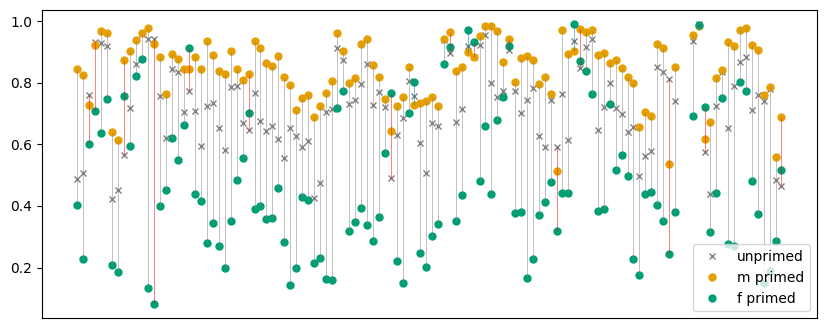

In [24]:
int_llama_neutral_prim_diffs = primed_completion_differences(llama32, 'internal', plot=True)

  0%|          | 0/60 [00:00<?, ?it/s]

2025-09-19 15:19:26.288 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range
2025-09-19 15:19:26.289 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range


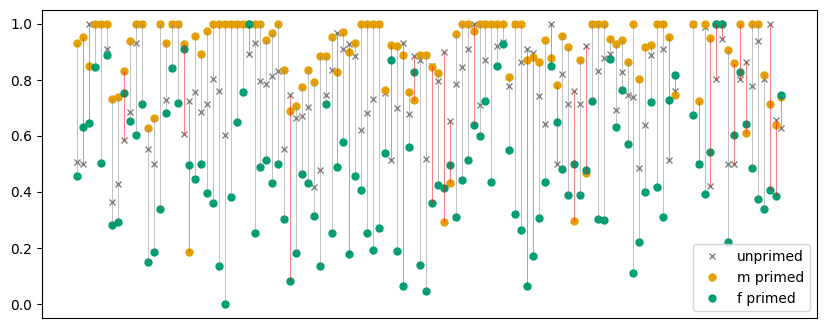

In [25]:
gen_llama_neutral_prim_diffs = primed_completion_differences(llama32, 'generation', plot=True)

### Mean Shifts

In [26]:
def mean_completion_shift(data: list[Measurement] | list[tuple],
                          mode: str | None = None,
                          max_index: int = 60):

    """
    Calculates the mean shift (across all ordered sentences pairs) in the probability of female pronoun production for
    mprimed and fprimed sentences. 

    :param data: list of Measurement objects (or equivalently structured dictionaries) OR 
         list of tuples from primed_completion_differences()
    :param mode: 'internal' or 'generation' (only necessary if data is a list of dicts/Measurements)
    :param max_index: maximum index in data (last index is thrown away)

    :returns: (mean shift mprimed, mean shift fprimed, array of shifts with mprimed, array of shifts with fprimed)
    
    """

    if isinstance(data[0], dict) or isinstance(data[0], Measurement):
        if mode is None:
            raise AttributeError("Must define mode if data is not a list of probability tupes")
        else:
            tuples = primed_completion_differences(data, mode, max_index, plot=False)
    else:
        tuples = data

    pruned_tuples = [t for t in tuples if is_valid_tuple(t)]

    unprimed_fprobs = np.array([t[0][1] for t in pruned_tuples])
    mprimed_fprobs = np.array([t[1][1] for t in pruned_tuples])
    fprimed_fprobs = np.array([t[2][1] for t in pruned_tuples])

    mshift = mprimed_fprobs - unprimed_fprobs
    fshift = fprimed_fprobs - unprimed_fprobs

    mean_mshift = np.nanmean(mshift)
    mean_fshift = np.nanmean(fshift)
    
    return mean_mshift, mean_fshift, mshift, fshift

In [27]:
int_llama32_shifts = mean_completion_shift(int_llama_neutral_prim_diffs)
gen_llama32_shifts = mean_completion_shift(gen_llama_neutral_prim_diffs)

In [28]:
int_llama32_shifts[:2], gen_llama32_shifts[:2]

((np.float64(0.11491992491839796), np.float64(-0.25158174506231973)),
 (np.float64(0.10554982805480874), np.float64(-0.29499788503676216)))

In [29]:
int_llama32_07_shifts = mean_completion_shift(llama32_07, mode='internal')
gen_llama32_07_shifts = mean_completion_shift(llama32_07, mode='generation')

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

2025-09-19 15:19:30.103 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range


In [30]:
int_llama32_03_shifts = mean_completion_shift(llama32_03, mode='internal')
gen_llama32_03_shifts = mean_completion_shift(llama32_03, mode='generation')

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

2025-09-19 15:19:33.074 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range
2025-09-19 15:19:33.074 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range
2025-09-19 15:19:33.075 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range
2025-09-19 15:19:33.075 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range
2025-09-19 15:19:33.134 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - Likely no measurements found. Exception raised: list index out of range


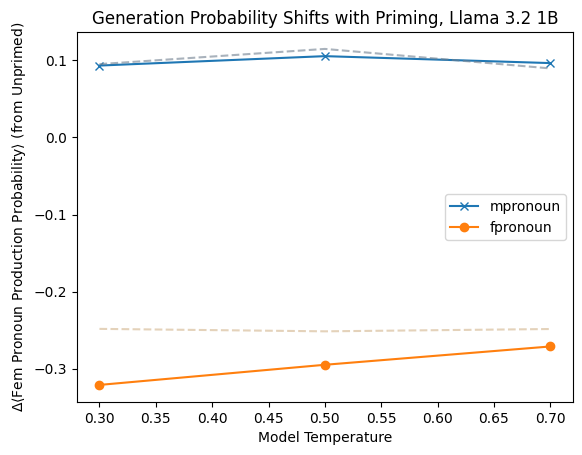

In [31]:
plt.plot([0.3, 0.5, 0.7],
         [gen_llama32_03_shifts[0], gen_llama32_shifts[0], gen_llama32_07_shifts[0]], label='mpronoun', marker='x')
plt.plot([0.3, 0.5, 0.7],
         [gen_llama32_03_shifts[1], gen_llama32_shifts[1], gen_llama32_07_shifts[1]], label='fpronoun', marker='o')

plt.plot([0.3, 0.5, 0.7],
         [int_llama32_03_shifts[0], int_llama32_shifts[0], int_llama32_07_shifts[0]],  linestyle='dashed', alpha=0.6,
        color='slategrey')
plt.plot([0.3, 0.5, 0.7],
         [int_llama32_03_shifts[1], int_llama32_shifts[1], int_llama32_07_shifts[1]],  linestyle='dashed', alpha=0.6,
        color='tan')

plt.ylabel(r"$\Delta \langle$Fem Pronoun Production Probability$\rangle$ (from Unprimed)")
plt.xlabel("Model Temperature")
plt.title("Generation Probability Shifts with Priming, Llama 3.2 1B")
plt.legend()

### Does it Depend on Occupation?

In [32]:
# ref_role, other_role
# {index: {forward: (ref_role, other_role), reverse: (ref_role, other_role)}}

pnoun_role_dict = defaultdict(dict)
for idx in range(max_llama):

    forward_sentence_idx = int((2 * idx) + 1)
    reverse_sentence_idx = int(2 * idx)

    answer_mapping = {0: 'occupation(0)', 1: 'other-participant(1)'}

    forward_ref_col = answer_mapping[templates['answer'][forward_sentence_idx]]
    forward_other_col = answer_mapping[(templates['answer'][forward_sentence_idx] + 1) % 2]
    reverse_ref_col = answer_mapping[templates['answer'][reverse_sentence_idx]]
    reverse_other_col = answer_mapping[(templates['answer'][reverse_sentence_idx] + 1) % 2]

    pnoun_role_dict[idx]['forward'] = (templates[forward_ref_col][forward_sentence_idx], templates[forward_other_col][forward_sentence_idx])
    pnoun_role_dict[idx]['reverse'] = (templates[reverse_ref_col][reverse_sentence_idx], templates[reverse_other_col][reverse_sentence_idx])

$$\operatorname{logit} P(X=1)=β_0 + β_O \cdot O + β_{P1} \cdot \mathbf{1}_{[Pr=m]}+β_{P2} \cdot \mathbf{1}_{[Pr=f]}$$

In [33]:
# Creating a df for the first index, only generation
# X, O, P

# THIS IS INCORRECT - THIS IS COMBINING BOTH.. SHOULD BE TWO SEPERATE.. or should it.. given the roles as a variable..

test_list_fwd = get_sent_order([0,1],get_index(0,llama32))
test_list_bwd = get_sent_order([1,0],get_index(0,llama32))
#test_list_fwd

forward_occ = pnoun_role_dict.get(0)['forward'][0]
reverse_occ = pnoun_role_dict.get(0)['reverse'][0]

forward_prime_list = [str(m['context']['pnoun_order'][0]) for m in test_list_fwd]
backward_prime_list = [str(m['context']['pnoun_order'][0]) for m in test_list_bwd]

fwd_measurement_list = [m['measurement']['BLANK'] for m in test_list_fwd if m['measurement']['BLANK'] is not None]
bwd_measurement_list = [m['measurement']['BLANK'] for m in test_list_bwd if m['measurement']['BLANK'] is not None]

fwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in test_list_fwd]
bwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in test_list_bwd]

llama_measurements_df = pd.DataFrame(data={
    'Measurement': fwd_measurement_list + bwd_measurement_list, 
    'Role': [forward_occ] * len(test_list_fwd) + [reverse_occ]*len(test_list_bwd),
    'GPrime': forward_prime_list + backward_prime_list,
    'POrder': fwd_measurement_pnoun_order + bwd_measurement_pnoun_order
})

llama_measurements_df["X"] = (llama_measurements_df["Measurement"] == "she").astype(int)

In [34]:
def create_regression_table(index: int, 
                            data: list[Measurement] | list[dict]):

    """
    Creates a DataFrame with columns [Measurement, Role, GPrime, POrder] for a *pair of sentences* using measurements provided. 

    :param data: List of Measurements (or equivalent dictionaries) 

    """

    fwd_list = get_sent_order([0,1],get_index(index,data, filter_none=True))
    bwd_list = get_sent_order([1,0],get_index(index,data, filter_none=True))

    forward_occ = pnoun_role_dict.get(index)['forward'][0]
    reverse_occ = pnoun_role_dict.get(index)['reverse'][0]

    fwd_prime_list = [str(m['context']['pnoun_order'][0]) for m in fwd_list]
    bwd_prime_list = [str(m['context']['pnoun_order'][0]) for m in bwd_list]

    fwd_measurement_list = [m['measurement']['BLANK'] for m in fwd_list if m['measurement']['BLANK'] is not None]
    bwd_measurement_list = [m['measurement']['BLANK'] for m in bwd_list if m['measurement']['BLANK'] is not None]

    fwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in fwd_list]
    bwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in bwd_list]

    measurements_df = pd.DataFrame(data={
    'Measurement': fwd_measurement_list + bwd_measurement_list, 
    'Role': [forward_occ] * len(fwd_list) + [reverse_occ]*len(bwd_list),
    'GPrime': fwd_prime_list + bwd_prime_list,
    'POrder': fwd_measurement_pnoun_order + bwd_measurement_pnoun_order
    })

    measurements_df["X"] = (measurements_df["Measurement"] == "she").astype(int)

    return measurements_df
    
    

In [35]:
def or_table(model):
    ci = model.conf_int()
    or_df = pd.DataFrame({
        "OR": np.exp(model.params),
        "CI_low": np.exp(ci[0]),
        "CI_high": np.exp(ci[1]),
        "p": model.pvalues
    })
    return or_df

In [36]:
def lrt(m_reduced, m_full):
    LR = 2 * (m_full.llf - m_reduced.llf)
    df = m_full.df_model - m_reduced.df_model
    p = stats.chi2.sf(LR, df)
    return {"LR": LR, "df": df, "p": p}

In [37]:
def metrics(model, data):
    p = model.predict(data)
    return {
        "log_loss": log_loss(data["X"], p, labels=[0, 1]),
        "AUC": roc_auc_score(data["X"], p)
    }

#### With Order

In [38]:
# THIS IS ONLY FOR A SINGLE INDEX

In [47]:
def shift_summary_table(order: bool,
                       data: list[Measurement] | list[dict],
                       max_index: int=60):

    """
    """

    out_df = defaultdict(list)
    
    for index in tqdm(range(max_index)):

        df = create_regression_table(index, data)

        try:
    
            if order:
                formula_main = "X ~ Role + C(GPrime, Treatment('None')) + POrder"
                m_noO = smf.logit("X ~ C(GPrime, Treatment('None')) + POrder", data=df).fit(disp=False)
                m_noP = smf.logit("X ~ Role + POrder", data=df).fit(disp=False)
                m_noPn = smf.logit("X ~ Role + C(GPrime, Treatment('None'))", data=df).fit(disp=False)
                
            else:
                formula_main = "X ~ Role + C(GPrime, Treatment('None'))"
                m_noO = smf.logit("X ~ C(GPrime, Treatment('None'))", data=df).fit(disp=False)
                m_noP = smf.logit("X ~ Role", data=df).fit(disp=False)
        
            m_full = smf.logit(formula_main, data=df).fit(disp=False)
            or_main = or_table(m_full)
            
        except Exception as e:
            logger.error(f"Error running regression for index {index}: {e}")
            continue
        
        # Likelihood Ratios
        lrt_O = lrt(m_noO, m_full) 
        lrt_P = lrt(m_noP, m_full)  
    
        # ML Metrics
        metrics_full = metrics(m_full, df)
        metrics_noO  = metrics(m_noO,  df)  
        metrics_noP  = metrics(m_noP,  df)  
         
        
        if order:
            lrt_Pn = lrt(m_noPn, m_full)
            metrics_noPn  = metrics(m_noPn,  df) 

        out_df['index'].append(index)
        out_df['or_intercept'].append(or_main.OR.values[0])
        out_df['or_intercept_p'].append(or_main.p.values[0])
        out_df['or_role'].append(or_main.OR.values[1])
        out_df['or_role_p'].append(or_main.p.values[1])
        out_df['or_mpronoun'].append(or_main.OR.values[2])
        out_df['or_mpronoun_p'].append(or_main.p.values[2])
        out_df['or_fpronoun'].append(or_main.OR.values[3])
        out_df['or_fpronoun_p'].append(or_main.p.values[3])
        if order:
            out_df['or_order'].append(or_main.OR.values[4])
            out_df['or_order_p'].append(or_main.p.values[4])
    
        out_df['lrt_role'].append(lrt_O['LR'])
        out_df['lrt_role_p'].append(lrt_O['p'])
        out_df['lrt_pronoun'].append(lrt_P['LR'])
        out_df['lrt_pronoun_p'].append(lrt_P['p'])
        if order:
            out_df['lrt_order'].append(lrt_Pn['LR'])
            out_df['lrt_order_p'].append(lrt_Pn['p'])
    
        out_df['log_loss_full'].append(metrics_full['log_loss'])
        out_df['AUC_full'].append(metrics_full['AUC'])
        out_df['log_loss_role'].append(metrics_noO['log_loss'])
        out_df['AUC_role'].append(metrics_noO['AUC'])
        out_df['log_loss_pronoun'].append(metrics_noP['log_loss'])
        out_df['AUC_pronoun'].append(metrics_noP['AUC'])
    
        if order:
            out_df['log_loss_order'].append(metrics_noPn['log_loss'])
            out_df['AUC_order'].append(metrics_noPn['AUC'])
    
    df_out = pd.DataFrame(data=out_df)
    out_df = df_out.set_index('index')
    
    
    return out_df    
        

In [48]:
test_summary_2 = shift_summary_table(True,llama32)

  0%|          | 0/60 [00:00<?, ?it/s]

/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect sep

2025-09-19 15:19:34.329 | ERROR    | __main__:shift_summary_table:31 - Error running regression for index 1: Singular matrix


/home/sagar/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/sagar/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihoo

2025-09-19 15:19:35.715 | ERROR    | __main__:shift_summary_table:31 - Error running regression for index 8: Singular matrix


...

2025-09-19 15:19:43.394 | ERROR    | __main__:shift_summary_table:31 - Error running regression for index 49: Singular matrix
2025-09-19 15:19:43.662 | ERROR    | __main__:shift_summary_table:31 - Error running regression for index 51: Singular matrix


/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparat

2025-09-19 15:19:44.327 | ERROR    | __main__:shift_summary_table:31 - Error running regression for index 54: Singular matrix


/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparat

2025-09-19 15:19:44.986 | ERROR    | __main__:shift_summary_table:31 - Error running regression for index 57: Singular matrix


In [49]:
# Log Odds Ratio Heatmap

def get_or_heatmap(table: pd.DataFrame, 
                  title: str = "Log-Odds Differences"):

    or_cols = ["or_role", "or_mpronoun", "or_fpronoun", "or_order"]
    log_or = np.log(table[or_cols].replace(0, np.nan))

    delta_log_or = pd.DataFrame({
    "Masc Priming Pronoun": log_or["or_mpronoun"] - log_or["or_role"],
    "Fem Priming Pronoun": log_or["or_fpronoun"] - log_or["or_role"],
    "Order": log_or["or_order"] - log_or["or_role"]
    })


    fig1, ax1 = plt.subplots(figsize=(6,6))
    im1 = ax1.imshow(delta_log_or, aspect="auto", interpolation="nearest", cmap="RdBu")
    ax1.set_title(title)
    ax1.set_xticks(range(delta_log_or.shape[1]))
    ax1.set_xticklabels(delta_log_or.columns, rotation=45, ha="right")
    ax1.set_yticks(range(len(table)))
    ax1.set_yticklabels(table.index, fontsize=6)

    cbar1 = fig1.colorbar(im1, ax=ax1)
    cbar1.set_label(r"$\log OR(x) - \log OR(\text{Role})$")
    plt.tight_layout()
    plt.show()

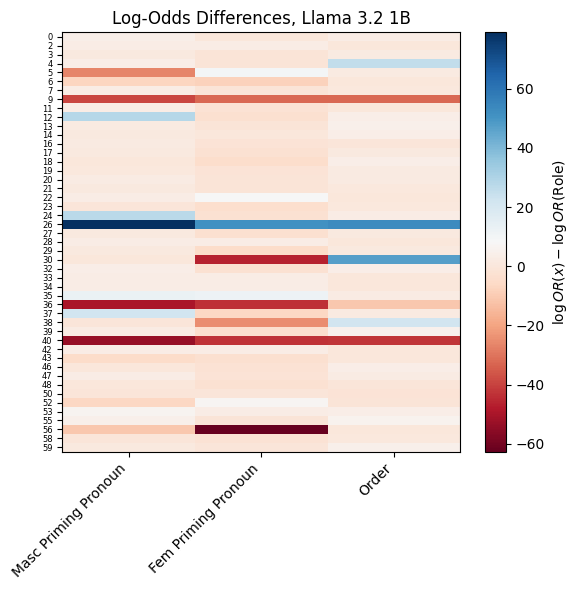

In [50]:
get_or_heatmap(test_summary_2, title="Log-Odds Differences, Llama 3.2 1B")

In [51]:
# AUC Heatmap

def get_auc_heatmap(table: pd.DataFrame,
                   title: str = "Ablation Study"):

    auc_cols = ["AUC_role", "AUC_full", "AUC_pronoun", "AUC_order"]
    auc = table[auc_cols]

    delta_auc = pd.DataFrame({
    "Full − Role": auc["AUC_full"] - auc["AUC_role"],
    "Full − Pronoun": auc["AUC_full"] - auc["AUC_pronoun"],
    "Full − Order": auc["AUC_full"] - auc["AUC_order"]
    })

    fig2, ax2 = plt.subplots(figsize=(6,6))
    im2 = ax2.imshow(delta_auc, aspect="auto", interpolation="nearest", cmap="Purples")
    ax2.set_title(title)
    ax2.set_xticks(range(delta_auc.shape[1]))
    ax2.set_xticklabels(delta_auc.columns, rotation=45, ha="right")
    ax2.set_yticks(range(len(table)))
    ax2.set_yticklabels(table.index, fontsize=6)

    cbar2 = fig2.colorbar(im2, ax=ax2)
    cbar2.set_label("AUC Difference")
    plt.tight_layout()
    plt.show()

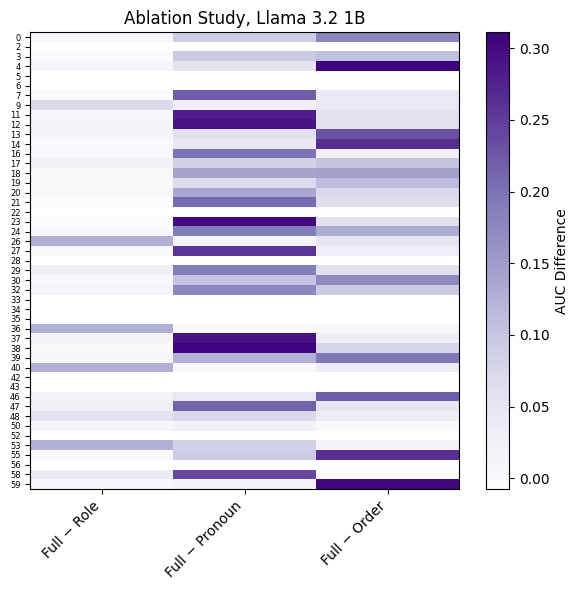

In [52]:
get_auc_heatmap(test_summary_2, "Ablation Study, Llama 3.2 1B")

#### Analysis Without Order

In [58]:
formula_main_no = "X ~ Role + C(GPrime, Treatment('None'))"

In [59]:
m_full_no = smf.logit(formula_main_no, data=llama_measurements_df).fit(disp=False)

In [60]:
# Odds Ratio
or_main_no = or_table(m_full_no)
or_main_no

,OR,CI_low,CI_high,p
Intercept,1.103728,0.920681,1.323168,2.860932e-01
Role[T.technician],0.845917,0.669802,1.068338,1.600363e-01
"C(GPrime, Treatment('None'))[T.he]",16.572213,10.097346,27.199053,1.159157e-28
"C(GPrime, Treatment('None'))[T.she]",1.256051,0.954584,1.652725,1.035173e-01


In [61]:
# Ablated Logit Models
m_noO_no = smf.logit("X ~ C(GPrime, Treatment('None'))", data=llama_measurements_df).fit(disp=False)
m_noP_no = smf.logit("X ~ Role", data=llama_measurements_df).fit(disp=False)

In [62]:
# Likelihood Ratios
lrt_O_no = lrt(m_noO_no, m_full_no) 
lrt_P_no = lrt(m_noP_no, m_full_no)  
lrt_O_no, lrt_P_no

({'LR': np.float64(1.9739581115795772),
  'df': 1.0,
  'p': np.float64(0.16002835677702423)},
 {'LR': np.float64(234.0937271337275),
  'df': 2.0,
  'p': np.float64(1.4695793095205707e-51)})

In [63]:
# ML Metrics
metrics_full_no = metrics(m_full_no, llama_measurements_df)
metrics_noO_no  = metrics(m_noO_no,  llama_measurements_df)  
metrics_noP_no  = metrics(m_noP_no,  llama_measurements_df) 

## Qwen 1.5

### Primed Completion Differences

  0%|          | 0/60 [00:00<?, ?it/s]

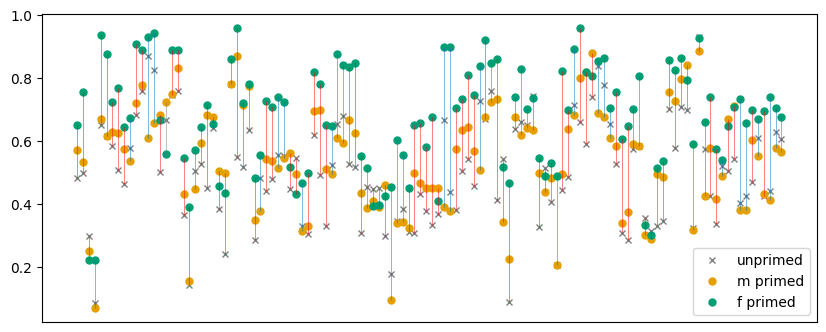

In [64]:
int_qwen_neutral_prim_diffs = primed_completion_differences(qwen15, 'internal', plot=True)

  0%|          | 0/60 [00:00<?, ?it/s]

/home/sagar/winogender_contextuality/winogender_contextuality/utils.py:241: RuntimeWarning: invalid value encountered in divide
  generation_probs = np.array(list(generation_counter_clean.values())) / num_valid_measurements


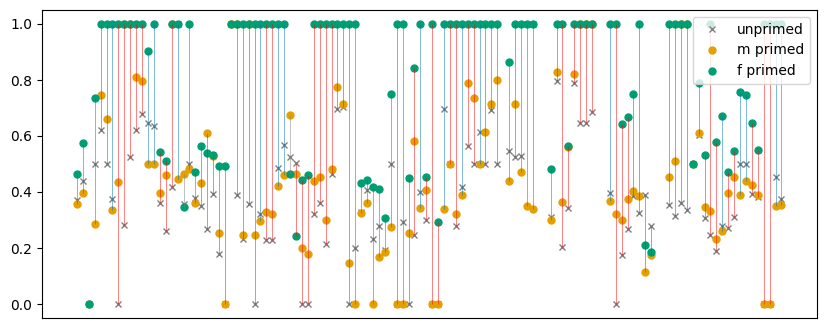

In [65]:
gen_qwen_neutral_prim_diffs = primed_completion_differences(qwen15, 'generation', plot=True)

### Mean Shifts

In [66]:
int_qwen15_shifts = mean_completion_shift(int_qwen_neutral_prim_diffs)
gen_qwen15_shifts = mean_completion_shift(gen_qwen_neutral_prim_diffs)

In [67]:
int_qwen15_shifts[:2], gen_qwen15_shifts[:2]

((np.float64(0.038127402209789725), np.float64(0.1731031944121804)),
 (np.float64(0.064307031291305), np.float64(0.41512131144856074)))

### Does it Depend on Occuptation?

In [68]:
qwen_full_wo = smf.logit(formula_main_wo, data=qwen_measurement_df).fit(disp=False)

NameError: name 'qwen_measurement_df' is not defined

In [ ]:
# Odds Ratio
qwen_or_main_wo = or_table(qwen_full_wo)
qwen_or_main_wo

## Phi 4

### Primed Completion Differences

In [ ]:
int_phi_neutral_prim_diffs = primed_completion_differences(phi, 'internal', plot=True)

In [ ]:
gen_phi_neutral_prim_diffs = primed_completion_differences(phi, 'generation', plot=True)

### Mean Shifts

### Does it Depend on Occupation

## GPT 

### First Pronoun Bias

In [69]:
internal_diffs = [
    mean_order_difference(gpt_03, single_only=True, mode='internal'),
    mean_order_difference(gpt, single_only=True, mode='internal'),
    mean_order_difference(gpt_07, single_only=True, mode='internal')
]

generation_diffs = [
    mean_order_difference(gpt_03, single_only=True, mode='generation'),
    mean_order_difference(gpt, single_only=True, mode='generation'),
    mean_order_difference(gpt_07, single_only=True, mode='generation')
]

temps = [0.3, 0.5, 0.7]

plt.plot(temps, internal_diffs, color='slategrey', alpha=0.6, linestyle='dotted')
plt.plot(temps, generation_diffs,  marker='x')

plt.title(r"$\langle p(fpro | mfirst) - p(fpro | ffirst) \rangle$, GPT OSS 20B") 

TypeError: list indices must be integers or slices, not str

### Primed Completion Differences

In [ ]:
int_gpt_neutral_prim_diffs = primed_completion_differences(gpt, 'internal', plot=True)

In [ ]:
gen_gpt_neutral_prim_diffs = primed_completion_differences(gpt, 'generation', plot=True)

### Mean Shifts

In [ ]:
int_gpt_shifts = mean_completion_shift(int_gpt_neutral_prim_diffs)
gen_gpt_shifts = mean_completion_shift(gen_gpt_neutral_prim_diffs)

In [ ]:
int_gpt_07_shifts = mean_completion_shift(gpt_07, mode='internal')
gen_gpt_07_shifts = mean_completion_shift(gpt_07, mode='generation')

In [ ]:
int_gpt_03_shifts = mean_completion_shift(gpt_03, mode='internal')
gen_gpt_03_shifts = mean_completion_shift(gpt_03, mode='generation')

In [ ]:
plt.plot([0.3, 0.5, 0.7],
         [gen_gpt_03_shifts[0], gen_gpt_shifts[0], gen_gpt_07_shifts[0]], label='mpronoun', marker='x')
plt.plot([0.3, 0.5, 0.7],
         [gen_gpt_03_shifts[1], gen_gpt_shifts[1], gen_gpt_07_shifts[1]], label='fpronoun', marker='o')

plt.plot([0.3, 0.5, 0.7],
         [int_gpt_03_shifts[0], int_gpt_shifts[0], int_gpt_07_shifts[0]],  linestyle='dashed', alpha=0.6,
        color='slategrey')
plt.plot([0.3, 0.5, 0.7],
         [int_gpt_03_shifts[1], int_gpt_shifts[1], int_gpt_07_shifts[1]],  linestyle='dashed', alpha=0.6,
        color='tan')

plt.ylabel(r"$\Delta \langle$Fem Pronoun Production Probability$\rangle$ (from Unprimed)")
plt.xlabel("Model Temperature")
plt.title("GPT OSS 20B")
plt.legend()

### Does it Depend on Occupation?

In [74]:
gpt_with_order = shift_summary_table(order=True,data=gpt)

  0%|          | 0/60 [00:00<?, ?it/s]

/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparatio

2025-09-19 15:26:53.300 | ERROR    | __main__:shift_summary_table:31 - Error running regression for index 1: Singular matrix


/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparat

2025-09-19 15:26:56.616 | ERROR    | __main__:shift_summary_table:31 - Error running regression for index 10: Singular matrix


/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sagar/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarnin

2025-09-19 15:27:01.814 | ERROR    | __main__:shift_summary_table:31 - Error running regression for index 26: Singular matrix


/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparat

2025-09-19 15:27:03.948 | ERROR    | __main__:shift_summary_table:31 - Error running regression for index 36: Singular matrix


/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sagar/miniconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/sagar/miniconda3/lib/python3.13/site-packages/pandas/core/

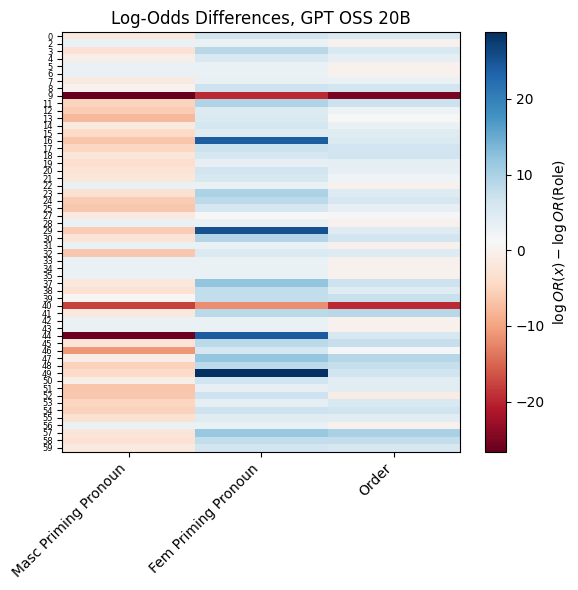

In [75]:
get_or_heatmap(gpt_with_order, title="Log-Odds Differences, GPT OSS 20B")

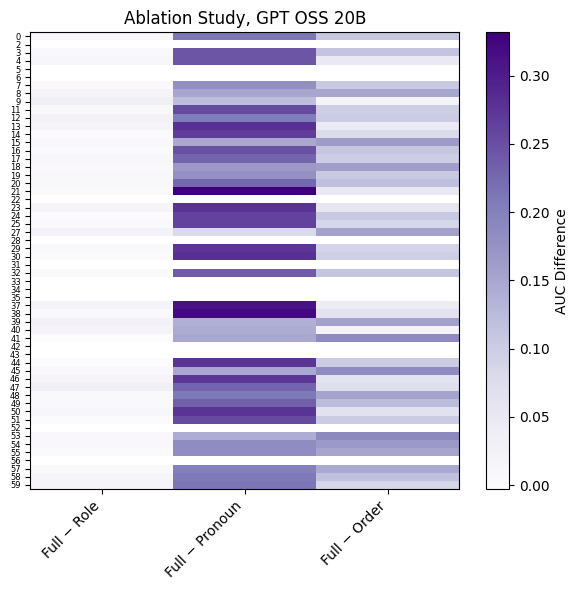

In [76]:
get_auc_heatmap(gpt_with_order, title="Ablation Study, GPT OSS 20B")

In [77]:
%%time
pooled_gpt = pooled_shift_summary(data=gpt, order=True)

CPU times: user 28min 38s, sys: 5.83 s, total: 28min 44s
Wall time: 4min 29s


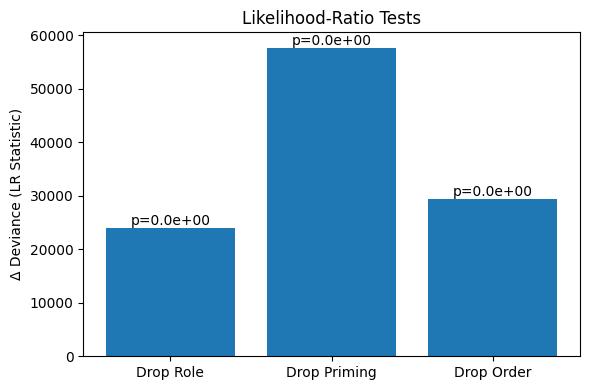

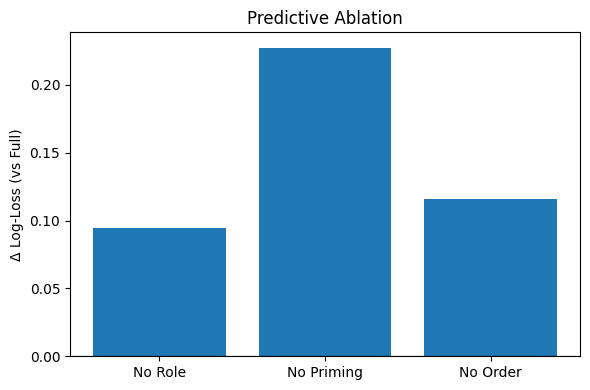

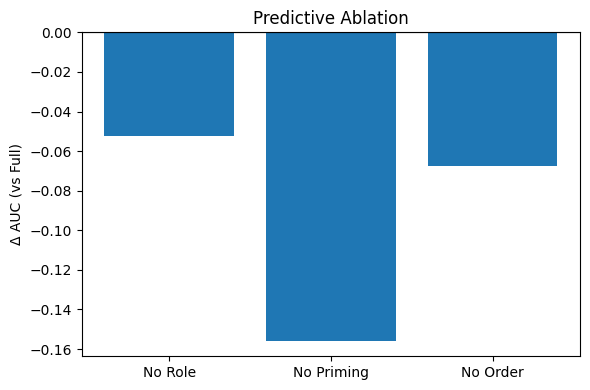

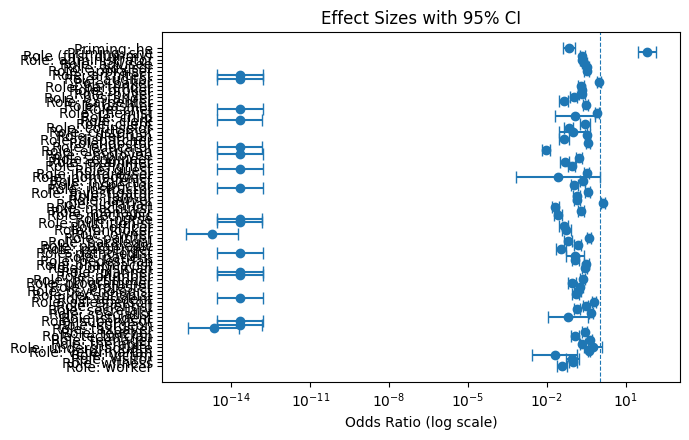

In [78]:
gpt_pooled_figs = plot_from_pooled_summary(pooled_gpt)

## Llama and GPT

In [ ]:
llama_internal_diffs = [
    mean_order_difference(llama32_03, single_only=True, mode='internal'),
    mean_order_difference(llama32, single_only=True, mode='internal'),
    mean_order_difference(llama32_07, single_only=True, mode='internal')
]

llama_generation_diffs = [
    mean_order_difference(llama32_03, single_only=True, mode='generation'),
    mean_order_difference(llama32, single_only=True, mode='generation'),
    mean_order_difference(llama32_07, single_only=True, mode='generation')
]

gpt_internal_diffs = [
    mean_order_difference(gpt_03, single_only=True, mode='internal'),
    mean_order_difference(gpt, single_only=True, mode='internal'),
    mean_order_difference(gpt_07, single_only=True, mode='internal')
]

gpt_generation_diffs = [
    mean_order_difference(gpt_03, single_only=True, mode='generation'),
    mean_order_difference(gpt, single_only=True, mode='generation'),
    mean_order_difference(gpt_07, single_only=True, mode='generation')
]

temps = [0.3, 0.5, 0.7]

plt.plot(temps, llama_generation_diffs,  marker='x', label='Llama 3.2 1B')
plt.plot(temps, llama_internal_diffs, color='slategrey', alpha=0.6, linestyle='dotted')

plt.plot(temps, gpt_generation_diffs,  marker='x', label='GPT OSS 20B')
plt.plot(temps, gpt_internal_diffs, color='tan', alpha=0.6, linestyle='dotted')

plt.ylim(-1,1)

plt.title(r"$\langle p(fpro | mfirst) - p(fpro | ffirst) \rangle$") 
plt.legend()

# Contextuality

In [ ]:
def get_contextuality_table(
    model_measurements: list[dict],
    default_pronoun: int = 1,  # 0 for male, 1 for female
    max_index: int = 60
) -> pd.DataFrame:

    indices = []
    
    mfirst_int = []
    ffirst_int = []

    mfirst_gen = []
    ffirst_gen = []
    
    for idx in tqdm(range(max_index)):

        try:

            # Internal 
            mfirst_int_data = sentence_order_single_results(idx, model_measurements, pnoun_order=0, mode='internal')
            mfirst_int_dc = calculate_sentence_dc_fraction(mfirst_int_data, mode='internal')
            
            ffirst_int_data = sentence_order_single_results(idx, model_measurements, pnoun_order=1, mode='internal')
            ffirst_int_dc = calculate_sentence_dc_fraction(ffirst_int_data, mode='internal')

            # Generation
            mfirst_gen_data = sentence_order_single_results(idx, model_measurements, pnoun_order=0, mode='generation')
            mfirst_gen_dc = calculate_sentence_dc_fraction(mfirst_gen_data, mode='generation')
            
            ffirst_gen_data = sentence_order_single_results(idx, model_measurements, pnoun_order=1, mode='generation')
            ffirst_gen_dc = calculate_sentence_dc_fraction(ffirst_gen_data, mode='generation')

            

        except Exception as e:
            logger.error(f"Error calculating degree of contextuality for index {idx}: {e}")
            continue

        indices.append(idx)
        mfirst_int.append(mfirst_int_dc)
        ffirst_int.append(ffirst_int_dc)
        mfirst_gen.append(mfirst_gen_dc)
        ffirst_gen.append(ffirst_gen_dc)

    out_df = pd.DataFrame(data={
        "index": indices,
        "int_mfirst": mfirst_int,
        "int_ffirst": ffirst_int,
        "gen_mfirst": mfirst_gen,
        "gen_ffirst": ffirst_gen
    })

    return out_df
        

In [ ]:
cont_llama_03 = get_contextuality_table(llama32_03)
cont_llama_05 = get_contextuality_table(llama32)
cont_llama_07 = get_contextuality_table(llama32_07)

In [ ]:
cont_gpt_03 = get_contextuality_table(gpt_03)
cont_gpt_05 = get_contextuality_table(gpt)
cont_gpt_07 = get_contextuality_table(gpt_07)

## Degree of Contextuality

In [ ]:
fig, axs = plt.subplots(2,2, sharey=True, sharex=True)
dist_bins = np.linspace(0,2,21)

axs[0,0].bar(cont_llama_05['index'], cont_llama_05['int_mfirst'])
axs[0,1].bar(cont_llama_05['index'], cont_llama_05['int_ffirst'])
axs[1,0].bar(cont_llama_05['index'], cont_llama_05['gen_mfirst'])
axs[1,1].bar(cont_llama_05['index'], cont_llama_05['gen_ffirst'])


axs[0,0].set_title('Male Pronoun First', fontsize=10)
axs[0,1].set_title('Female Pronoun First', fontsize=10)
axs[0,0].set_ylabel(r'Model $\Delta C$', )
axs[1,0].set_ylabel(r'Generation $\Delta C$')

fig.suptitle('Contextuality in Llama 3.2 1B')
plt.tight_layout()

In [ ]:
fig, axs = plt.subplots(2,2, sharey=True, sharex=True)
dist_bins = np.linspace(0,2,21)

axs[0,0].bar(cont_gpt_05['index'], cont_gpt_05['int_mfirst'])
axs[0,1].bar(cont_gpt_05['index'], cont_gpt_05['int_ffirst'])
axs[1,0].bar(cont_gpt_05['index'], cont_gpt_05['gen_mfirst'])
axs[1,1].bar(cont_gpt_05['index'], cont_gpt_05['gen_ffirst'])


axs[0,0].set_title('Male Pronoun First', fontsize=10)
axs[0,1].set_title('Female Pronoun First', fontsize=10)
axs[0,0].set_ylabel(r'Model $\Delta C$', )
axs[1,0].set_ylabel(r'Generation $\Delta C$')

fig.suptitle('Contextuality in GPT OSS 20B')
plt.tight_layout()

## Number of contextual pairs 

In [ ]:
# Count of Number of Contextual Pairs
(cont_llama_03 > 0).sum(), (cont_llama_05 > 0).sum(), (cont_llama_07 > 0).sum()

In [ ]:
(cont_gpt_03 > 0).sum(), (cont_gpt_05 > 0).sum(), (cont_gpt_07 > 0).sum()

In [ ]:
plt.plot(temps,
        [(cont_llama_03 > 0).sum()['gen_mfirst'], (cont_llama_05 > 0).sum()['gen_mfirst'], (cont_llama_07 > 0).sum()['gen_mfirst']],
        marker='x',
        color='dodgerblue',
        label='llama mfirst')
plt.plot(temps,
        [(cont_llama_03 > 0).sum()['gen_ffirst'], (cont_llama_05 > 0).sum()['gen_ffirst'], (cont_llama_07 > 0).sum()['gen_ffirst']],
        marker='o',
        color='dodgerblue',
        label='llama ffirst')

plt.plot(temps,
        [(cont_gpt_03 > 0).sum()['gen_mfirst'], (cont_gpt_05 > 0).sum()['gen_mfirst'], (cont_gpt_07 > 0).sum()['gen_mfirst']],
        marker='x',
        color='darkorange',
        label='gpt mfirst')
plt.plot(temps,
        [(cont_gpt_03 > 0).sum()['gen_ffirst'], (cont_gpt_05 > 0).sum()['gen_ffirst'], (cont_gpt_07 > 0).sum()['gen_ffirst']],
        marker='o',
        color='darkorange',
        label='gpt ffirst')
plt.xlabel("Model Temperature")
plt.ylabel("Number of Contextual Pairs")
plt.legend()